In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from ExtremeLearningMachine import ExtremeLearningMachine

In [2]:
filePath = '../../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)
# Separate Features and Target
targetCol = ['Gallstone Status']
X = df.drop(targetCol, axis=1)
y = df[targetCol]

In [3]:
set_k_fold  = 5
set_hidden_size = 25
set_random_state = 40
set_regularization_lambda = 0.0
set_activation_function = np.tanh

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [5]:
def benchmark_elm_performance(dataframe,
                              target_col,
                              hidden_sizes,
                              k_fold = 10,
                              activation_function = np.tanh,
                              regularization_lambda =0.0 ,
                              random_state=42):

    training_features = dataframe.drop(target_col, axis=1)
    target_features = dataframe[target_col]
    x_train_full, x_test, y_train_full, y_test = train_test_split(
        training_features,
        target_features,
        test_size=0.2,
        random_state=random_state,
        stratify=target_features
    )

    y_train_vals = y_train_full.values.ravel()
    results_summary = []

    for h_size in hidden_sizes:
        skf = StratifiedKFold(n_splits = k_fold, shuffle = True, random_state = random_state)

        cv_metrics = {
            'accuracy'      : [],
            'precision'     : [],
            'recall'        : [],
            'specificity'   : [],
            'f1-score'      : []
        }

        for training_index, validating_index in skf.split(x_train_full, y_train_vals):
            x_training_fold, x_validating_fold = x_train_full.values[training_index], x_train_full.values[validating_index]
            y_training_fold, y_validating_fold = y_train_vals[training_index], y_train_vals[validating_index]

            scaler = MinMaxScaler()
            x_training_fold_scaled = scaler.fit_transform(x_training_fold)
            x_validating_fold_scaled = scaler.transform(x_validating_fold)

            cv_model = ExtremeLearningMachine(
                features_size=x_training_fold.shape[1],
                hidden_size=h_size ,
                activation_function=activation_function,
                regularization_lambda=regularization_lambda
            )

            cv_model.initialize_random_weights(random_seed=random_state)
            cv_model.regularized_fit(x_training_fold_scaled, y_training_fold, regularization_lambda)

            # Trigger metrics calculation for the current fold
            cv_model.set_evaluation_metrics(x_validating_fold_scaled, y_validating_fold)
            m_fold = cv_model.get_evaluation_metrics()

            cv_metrics['accuracy'].append(m_fold[0])
            cv_metrics['precision'].append(m_fold[1])
            cv_metrics['recall'].append(m_fold[2])
            cv_metrics['specificity'].append(m_fold[3])
            cv_metrics['f1-score'].append(m_fold[4])



        final_scaler = MinMaxScaler()
        x_train_final = final_scaler.fit_transform(x_train_full)
        x_test_final = final_scaler.transform(x_test)

        test_model = ExtremeLearningMachine(
            features_size=x_train_full.shape[1],
            hidden_size=h_size,
            activation_function=activation_function,
            regularization_lambda=regularization_lambda
        )
        test_model.initialize_random_weights(random_seed=random_state)
        test_model.regularized_fit(x_train_final, y_train_vals, regularization_lambda)
        test_model.set_evaluation_metrics(x_test_final, y_test.values.ravel())
        m_test = test_model.get_evaluation_metrics()

        # Build the result row with Min, Max, and Avg for CV metrics
        row = {'hidden_nodes': h_size}

        for metric_name, values in cv_metrics.items():
            row[f'cv_{metric_name}_avg'] = np.mean(values)
            row[f'cv_{metric_name}_min'] = np.min(values)
            row[f'cv_{metric_name}_max'] = np.max(values)
            row[f'cv_{metric_name}_std'] = np.std(values) # Added standard deviation

        # Add final test results
        row.update({
            'test_accuracy': m_test[0],
            'test_precision': m_test[1],
            'test_recall': m_test[2],
            'test_specificity': m_test[3],
            'test_f1-score': m_test[4]
        })

        results_summary.append(row)

    return pd.DataFrame(results_summary)

In [6]:
datasets_config = {
    "Gallstone": {"path": "../../Dataset/UCI_Gallstone_Dataset.csv", "target": "Gallstone Status"},
    "Dataset":   {"path": "../../Dataset/Dataset.csv", "target": "Gallstone Status"} # Assuming same target name
}

node_configs = list(range(1, 251, 1))
all_reports = {}

for name, config in datasets_config.items():
    try:
        data = pd.read_csv(config["path"])
        report = benchmark_elm_performance(
            data,
            config["target"],
            node_configs,
            k_fold=set_k_fold,
            regularization_lambda=set_regularization_lambda,
            random_state=set_random_state
        )
        all_reports[name] = report
    except FileNotFoundError:
        print(f"Error: File not found at {config['path']}")
    except Exception as e:
        print(f"An error occurred with {name}: {e}")


gallstone_report = all_reports.get("Gallstone")
dataset_report = all_reports.get("Dataset")

In [7]:
def plot_elm_robustness(report_df, dataset_name):
    sns.set_theme(style="whitegrid")

    metrics = [
        ('accuracy', 'Accuracy'),
        ('precision', 'Precision'),
        ('recall', 'Recall'),
        ('specificity', 'Specificity'),
        ('f1-score', 'F1-Score')
    ]

    for key, metric_name in metrics:
        plt.figure(figsize=(12, 7))

        nodes = report_df['hidden_nodes']
        avg = report_df[f'cv_{key}_avg']
        y_min = report_df[f'cv_{key}_min']
        y_max = report_df[f'cv_{key}_max']
        std = report_df[f'cv_{key}_std']
        test = report_df[f'test_{key}']

        # 1. Plot Min, Avg, Max Lines
        plt.plot(nodes, avg, color='blue', linewidth=0.8, label=f'Avg {metric_name}', marker='o')
        plt.plot(nodes, y_min, color='skyblue', linestyle='--', linewidth=0.5, label=f'Min {metric_name}')
        plt.plot(nodes, y_max, color='navy', linestyle='--', linewidth=0.5, label=f'Max {metric_name}')

        # 2. Add Shaded Area for Standard Deviation
        plt.fill_between(nodes, avg - std, avg + std, color='blue', alpha=0.15, label='Std Dev Range')

        # 3. Plot the Final Holdout Test result
        plt.plot(nodes, test, color='red', linewidth=0.8, label=f'Final Test {metric_name}', marker='s')

        # Formatting
        plt.title(f'{dataset_name}: {metric_name} Analysis', fontsize=15, pad=15)
        plt.xlabel('Number of Hidden Nodes', fontsize=12)
        plt.ylabel(f'{metric_name} Score', fontsize=12)
        plt.legend(loc='lower right', frameon=True, shadow=True)
        plt.ylim(-0.01, 1.01) # Keep scale consistent for 0-1 metrics
        plt.grid(True, linestyle=':', alpha=0.6)

        plt.tight_layout()
        plt.show()


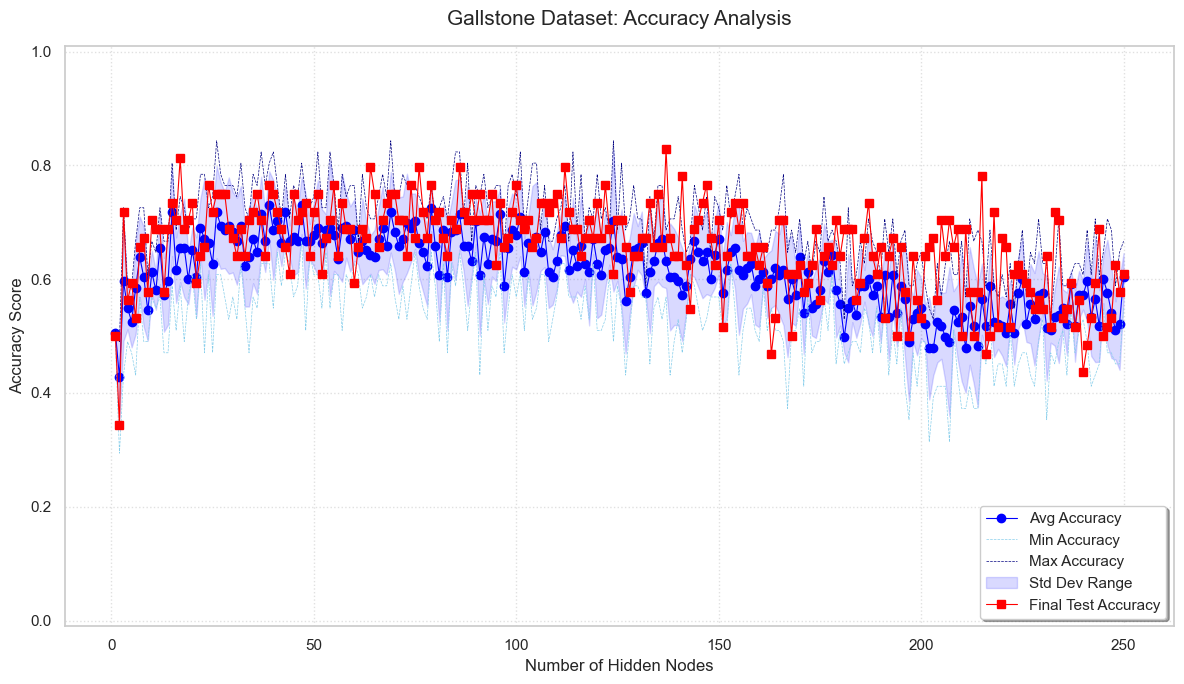

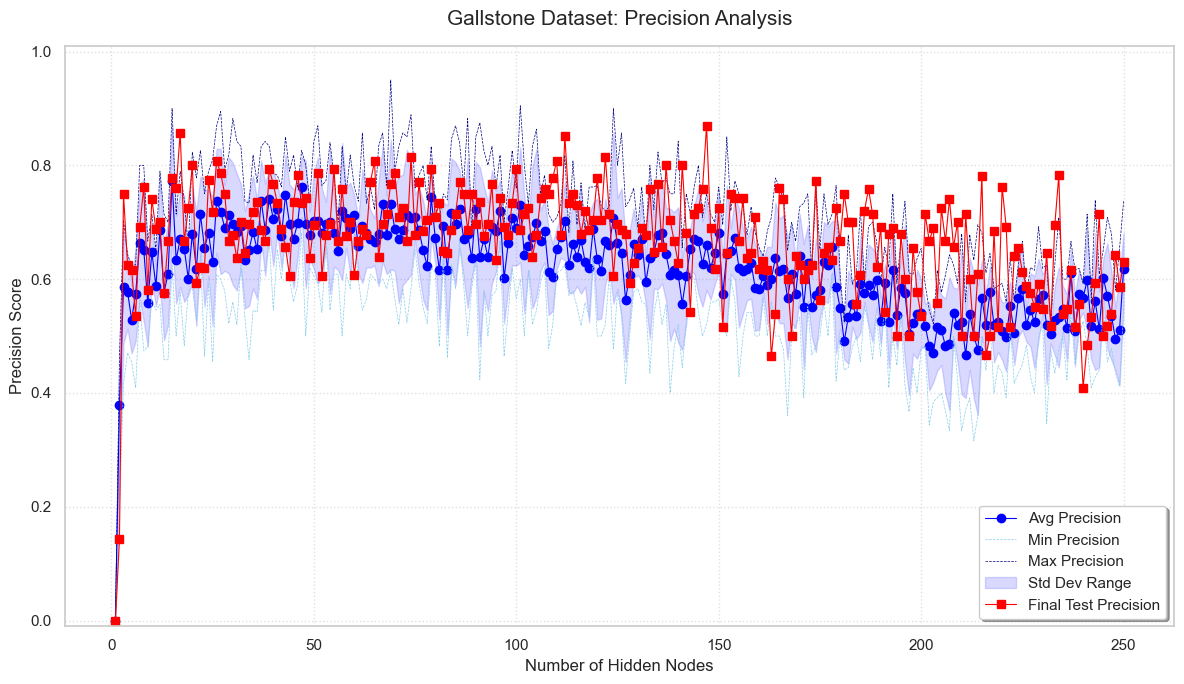

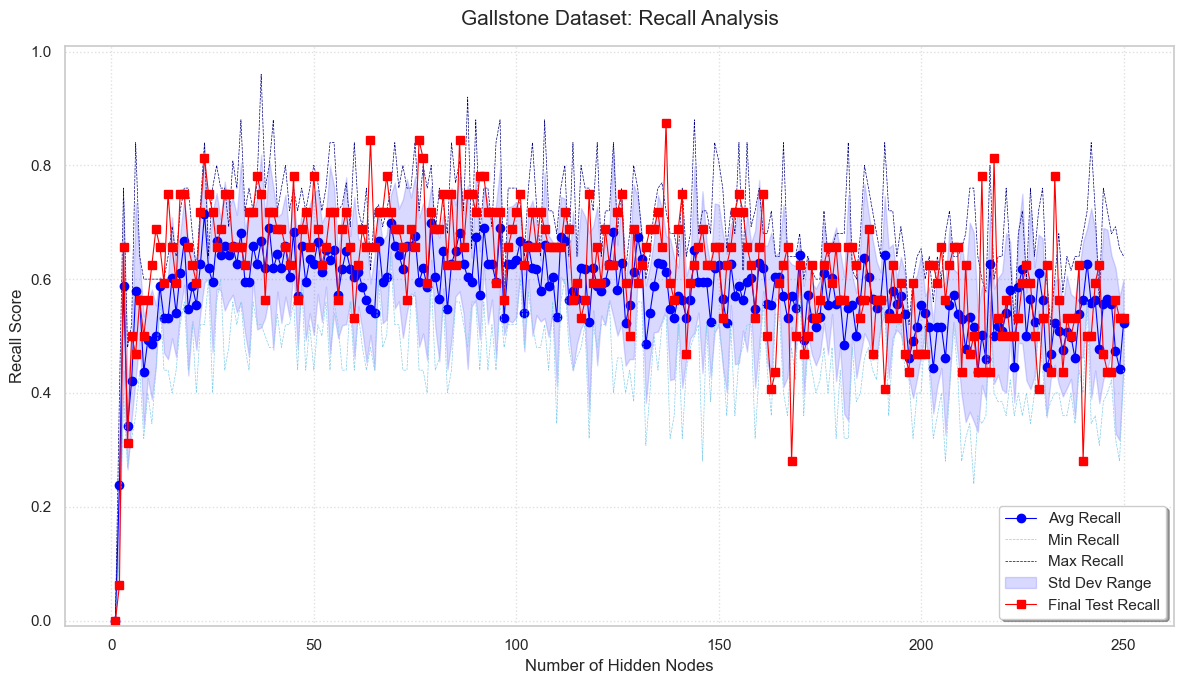

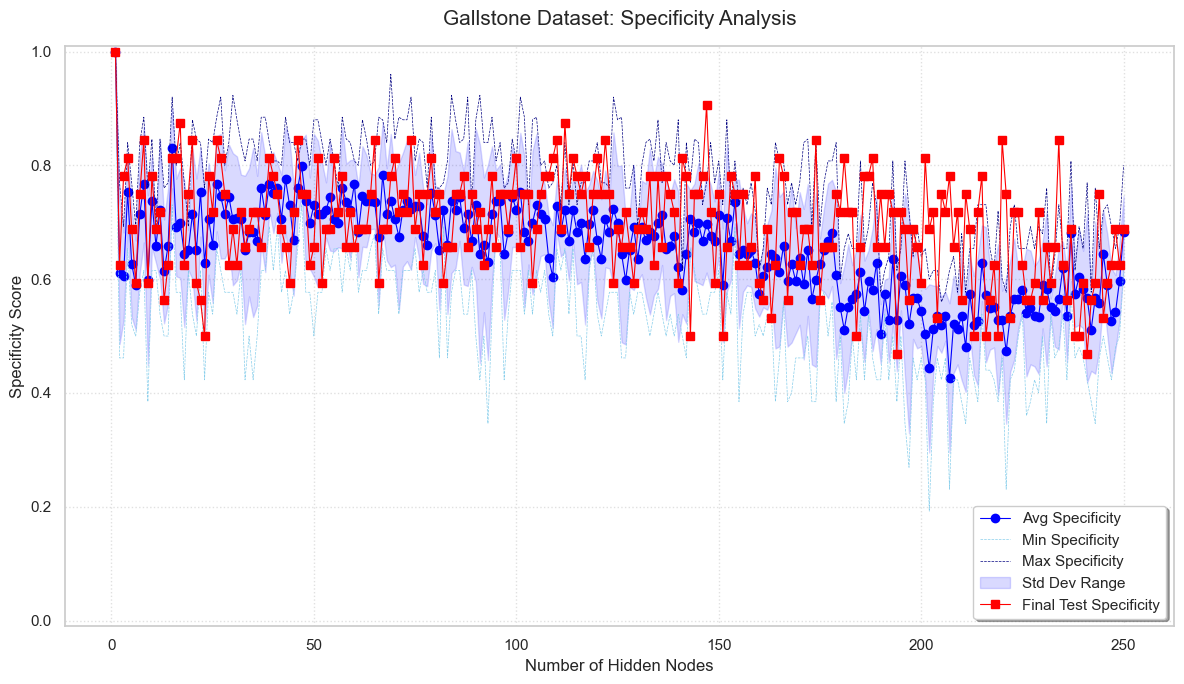

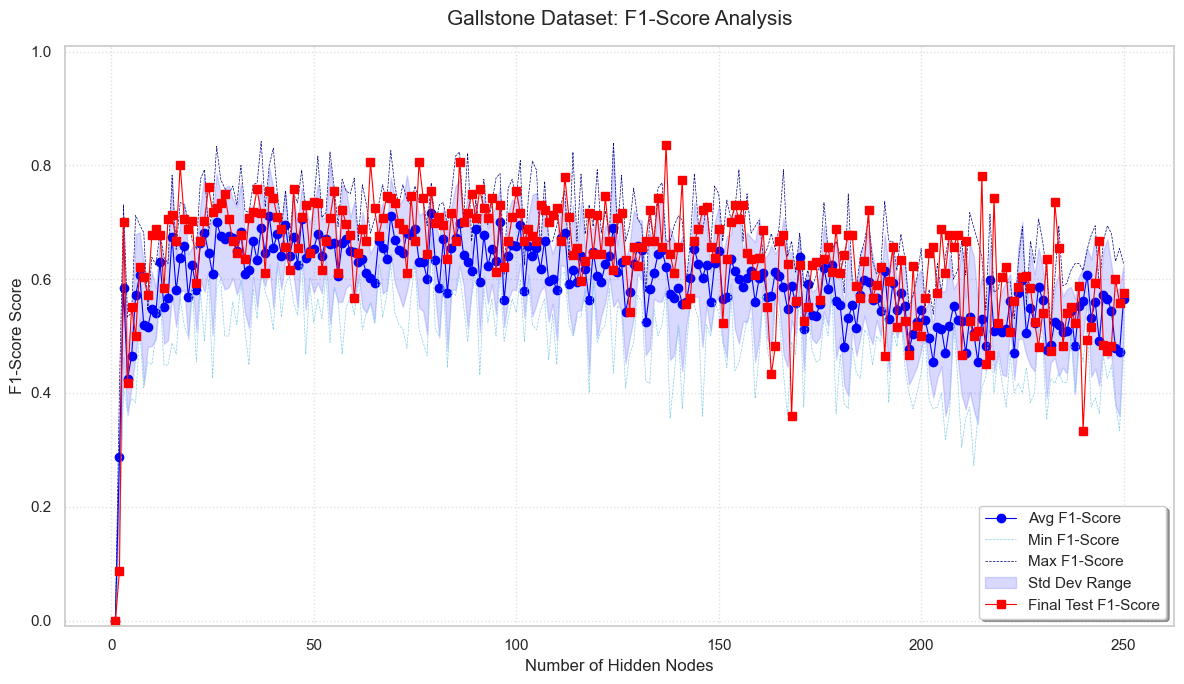

In [8]:
plot_elm_robustness(gallstone_report, "Gallstone Dataset")

In [9]:
def rank_robust_elm_nodes(report_df, penalty_multiplier=1.0):
    # 1. Define base weights for the averages
    weights = {
        'accuracy': 0.30,
        'f1-score': 0.30,
        'recall': 0.30,
        'specificity': 0.10
    }

    scored_df = report_df.copy()

    # 2. Calculate Robust Score for each metric
    # Formula: (Avg - Penalty * Std)
    for metric in weights.keys():
        avg_col = f'cv_{metric}_avg'
        std_col = f'cv_{metric}_std'
        scored_df[f'robust_{metric}'] = scored_df[avg_col] - (penalty_multiplier * scored_df[std_col])

    # 3. Calculate Final Weighted Robust Score
    scored_df['final_robust_score'] = sum(
        scored_df[f'robust_{metric}'] * weight for metric, weight in weights.items()
    )

    # 4. Sort by Robustness and take top 10
    top_10 = scored_df.sort_values(by='final_robust_score', ascending=False).head(10)

    # Clean output for readability
    display_cols = ['hidden_nodes', 'final_robust_score', 'cv_accuracy_avg','cv_f1-score_avg','cv_recall_avg','cv_specificity_avg']
    return top_10[display_cols].reset_index(drop=True)


robust_top_10 = rank_robust_elm_nodes(gallstone_report)
robust_top_10

,hidden_nodes,final_robust_score,cv_accuracy_avg,cv_f1-score_avg,cv_recall_avg,cv_specificity_avg
0,79,0.665006,0.725490,0.715395,0.698462,0.752000
1,47,0.655129,0.729412,0.706283,0.659077,0.798154
2,69,0.644068,0.717647,0.711371,0.698154,0.738154
3,96,0.635054,0.713725,0.701052,0.690462,0.737231
4,41,0.632265,0.701961,0.679887,0.643692,0.760000
5,43,0.632210,0.717647,0.695599,0.658769,0.775692
6,39,0.632030,0.729412,0.710742,0.689846,0.768000
7,53,0.630358,0.686275,0.670748,0.650769,0.721538
8,101,0.630012,0.709804,0.695342,0.666154,0.753231
9,111,0.625128,0.678431,0.672779,0.674154,0.682462


In [10]:
# 1. DEFINE the function once (Do not put this inside a loop)
def elm_performance(dataframe, target_col, hidden_sizes, activation_function=np.tanh, regularization_lambda=0.0, random_state=42):
    # ... (Keep the function body exactly as you have it) ...

    # 1. SPLIT
    X = dataframe.drop(target_col, axis=1)
    y = dataframe[target_col]

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    # 2. SCALE
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    y_train_vals = y_train.values.ravel()
    y_test_vals = y_test.values.ravel()

    results = []

    # 3. EVALUATE (The function loops through the list for you!)
    for h_size in hidden_sizes:
        model = ExtremeLearningMachine(
            features_size=x_train_scaled.shape[1],
            hidden_size=h_size,
            activation_function=activation_function,
            regularization_lambda=regularization_lambda
        )

        model.initialize_random_weights(random_seed=random_state)
        model.regularized_fit(x_train_scaled, y_train_vals, regularization_lambda)

        model.set_evaluation_metrics(x_test_scaled, y_test_vals)
        metrics = model.get_evaluation_metrics()

        results.append({
            'hidden_nodes': h_size,
            'final_test_accuracy': metrics[0],
            'final_test_precision': metrics[1],
            'final_test_recall': metrics[2],
            'final_test_specificity': metrics[3],
            'final_test_f1': metrics[4]
        })

    return pd.DataFrame(results)

# 2. EXECUTION (Run this part after defining the function)

# A. Extract the list of robust nodes you found earlier
robust_node_list = robust_top_10['hidden_nodes'].tolist()

# B. Pass that WHOLE LIST into the function
# (Replace 'df' and 'target' with your actual variable names)
final_test_results = elm_performance(
    dataframe=df,
    target_col=targetCol,
    hidden_sizes=robust_node_list,
    activation_function=np.tanh,
    regularization_lambda=0.0,
    random_state=set_random_state
)

# C. View the results
final_test_results

,hidden_nodes,final_test_accuracy,final_test_precision,final_test_recall,final_test_specificity,final_test_f1
0,79,0.765625,0.793103,0.71875,0.81250,0.754098
1,47,0.718750,0.733333,0.68750,0.75000,0.709677
2,69,0.750000,0.766667,0.71875,0.78125,0.741935
3,96,0.734375,0.741935,0.71875,0.75000,0.730159
4,41,0.718750,0.733333,0.68750,0.75000,0.709677
5,43,0.656250,0.656250,0.65625,0.65625,0.656250
6,39,0.765625,0.793103,0.71875,0.81250,0.754098
7,53,0.671875,0.677419,0.65625,0.68750,0.666667
8,101,0.703125,0.685714,0.75000,0.65625,0.716418
9,111,0.671875,0.677419,0.65625,0.68750,0.666667
